In [1]:
import os
import gc
import copy
import torch
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

import timm
from torch import nn
from torch.optim import Adam
from torchvision import models
import torch.nn.functional as F
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from typing import Callable,Tuple, List
from PIL import Image

In [2]:
# Check accelerator

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f'Using {device} device')

Using cuda device


In [3]:
# Set SEED for reproducibility

SEED = 24520152

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
# Train directory path

TRAIN_DIR = '/kaggle/input/datasets/hophamsailam/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'
TRAIN_DIR

'/kaggle/input/datasets/hophamsailam/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'

In [5]:
# Save directory path

SAVE_DIR = '/kaggle/working/'
SAVE_DIR

'/kaggle/working/'

In [6]:
# 3 labels: Glioma Tumor, Meningioma Tumor, Pituitary Tumor
CLASS_NAMES = sorted([d for d in os.listdir(os.path.join(TRAIN_DIR, 'Subset_1')) if os.path.isdir(os.path.join(TRAIN_DIR, 'Subset_1', d))])
CLASS_NAMES

['Glioma Tumor', 'Meningioma Tumor', 'Pituitary Tumor']

In [7]:
# DenseNet121
MODEL1_DIR = '/kaggle/input/datasets/uynnht/densenet121-5fcv-hieu-32'
# Mobilenet
MODEL2_DIR = '/kaggle/input/datasets/uynnht/mobilenet-5fcv-hieu-42'
# Resnet50
MODEL3_DIR = '/kaggle/input/datasets/xvmhieu/resnet50-5fcv-hieu-32'

In [8]:
# Model name
MODEL1_NAME = 'DenseNet121'
MODEL2_NAME = 'MobileNet'
MODEL3_NAME = 'ResNet50'
# MODEL4_NAME = 'VGG19'

MODEL_ENSEMBLE_NAME = f'tta-{MODEL1_NAME}_{MODEL2_NAME}-{MODEL3_NAME}'

In [9]:
# Hyperparameters

BATCH_SIZE = 32
EPOCHS = 100
NUM_CLASSES = 3
DROPOUT_RATE = 0.3
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

In [10]:
DATASET_CACHE = {}

def get_valid_data_for_fold(k: int, train_dir: str = TRAIN_DIR, batch_size: int = BATCH_SIZE) -> DataLoader:
    """
    Retrieves the validation DataLoader for a specific fold with caching mechanism.
    This function checks if the validation loader for the specified fold `k` is already
    present in the global `DATASET_CACHE`. If found, it returns the cached loader to save memory 
    and processing time. If not, it generates the loader using `get_data_for_fold`, caches it, 
    and then returns it.

    Args:
        k (int): The fold index (e.g., 1 to 5) identifying which subset is used for validation.
        train_dir (str, optional): The root directory path of the training data. 
            Defaults to global TRAIN_DIR.
        batch_size (int, optional): The number of samples per batch to load. 
            Defaults to global BATCH_SIZE.

    Returns:
        DataLoader: The PyTorch DataLoader containing the validation dataset for fold `k`.
    """
    
    # 1. Check if the loader for this fold is already in the cache
    if k in DATASET_CACHE:
        return DATASET_CACHE[k]
    
    # 2. If not in cache, create new loaders
    # Only need val_loader
    _, val_loader = get_data_for_fold(k=k, train_dir=train_dir, batch_size=batch_size)
    
    # 3. Store the newly created validation loader in the cache
    DATASET_CACHE[k] = val_loader

    return val_loader

In [11]:
def get_data_for_fold(k: int, train_dir: str = TRAIN_DIR, batch_size: int = BATCH_SIZE) -> tuple[DataLoader, DataLoader]:
    """
    Creates PyTorch DataLoaders for K-Fold Cross-Validation, specifically tailored
    for transfer learning with ImageNet standards.

    This function sets up a data pipeline that:
    1. Applies standard ImageNet normalization statistics.
    2. Implements strong data augmentation for the training set (using torchvision v2).
    3. Prepares validation data with deterministic preprocessing (Resize -> CenterCrop).
    4. Handles subset selection based on the current fold index 'k'.

    Args:
        k (int): The index of the validation fold (e.g., 1 to 5). 
                 The folder 'Subset_{k}' will be used for validation, while 
                 all other subsets are concatenated for training.
        train_dir (str): Path to the root directory containing the fold subsets 
                         (e.g., 'Subset_1', 'Subset_2', etc.).
        batch_size (int, optional): Number of samples per batch. Defaults to 32.

    Returns:
        tuple: A tuple containing:
            - train_loader (DataLoader): The training data loader (shuffled).
            - val_loader (DataLoader): The validation data loader (not shuffled).
    """

    # Standard ImageNet normalization statistics (Required for VGG19 weights)
    norm_mean=[0.485, 0.456, 0.406]
    norm_std=[0.229, 0.224, 0.225]

    # Training Transform Pipeline
    train_transform = v2.Compose([
        # Resize to 256x256 first. This provides a buffer for subsequent 
        # rotation/translation and cropping, preventing black border artifacts.
        v2.Resize(size=256),

        # Apply Data Augmentation
        v2.RandomHorizontalFlip(),
        v2.RandomRotation(degrees=36),
        v2.RandomAffine(degrees=0, scale=(0.9, 1.1)),
        v2.ColorJitter(brightness=0.1, contrast=0.1),

        # Use CenterCrop to focus on the primary subject
        v2.CenterCrop(size=224),

        # Convert PIL/Numpy to Tensor, cast to Float32, and rescale to [0, 1]
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),

        # Normalize using ImageNet mean and std
        v2.Normalize(mean=norm_mean, std=norm_std),
    ])

    # Validation Transform Pipeline
    val_transform = v2.Compose([
        v2.Resize(size=256),
        v2.CenterCrop(size=224),
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
        v2.Normalize(mean=norm_mean, std=norm_std)
    ])

    # Data Path Setup
    val_dir = os.path.join(train_dir, f'Subset_{k}')
    train_dirs = [os.path.join(train_dir, f'Subset_{i}') for i in range(1, 6) if i != k]

    # Worker Configuration
    # Determine the optimal number of CPU workers to prevent bottlenecks.
    # Capped at 4 to avoid excessive memory overhead.
    num_workers = min(4, os.cpu_count())

    # Validation Loader
    val_dataset = ImageFolder(root=val_dir, transform=val_transform)
    val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    # Training Loader
    list_train_dataset = [ImageFolder(root=td, transform=train_transform) for td in train_dirs]
    train_dataset = ConcatDataset(datasets=list_train_dataset)
    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader

In [12]:
class DenseNet121(nn.Module):
    """
    DenseNet121-based model for image classification using Transfer Learning.
    
    Architecture:
    - Backbone: DenseNet121 (frozen, ImageNet weights)
    - Head: Global Average Pooling -> Dropout -> Linear (Dense)
    
    Attributes:
        num_classes (int): Number of target classes.
        dropout_rate (float): Dropout probability.
    """
    
    def __init__(self, num_classes: int = 3, dropout_rate: float = 0.3) -> None:
        super().__init__()

        # Load Pre-trained DenseNet121
        weights = models.DenseNet121_Weights.IMAGENET1K_V1
        backbone = models.densenet121(weights=weights)

        # DenseNet121 .features contains all Conv/Relu/MaxPool layers
        self.features = backbone.features

        # Freezing parameters to prevent updating during training
        for param in self.features.parameters():
            param.requires_grad = False

        # Define Custom Classifier Head.
        self.in_features = 1024 
        self.global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1) # Reduces (Batch, 1024, H, W) -> (Batch, 1024, 1, 1)
        self.flatten = nn.Flatten(start_dim=1) # Flatten (Batch, 1024, 1, 1) -> (Batch, 1024)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(in_features=self.in_features, out_features=num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the model.

        Args:
            x (torch.Tensor): Input image batch (B, C, H, W).
                              Expected standard ImageNet normalization.

        Returns:
            torch.Tensor: Raw logits (B, num_classes). 
                          NOTE: Does NOT apply Softmax.
        """
        
        # Feature extraction (Frozen)
        x = self.features(x)
        # The torchvision.models.densenet121 `.features` block ends with a 
        # BatchNorm layer (norm5), which outputs both negative and positive values.
        # We MUST apply ReLU here to zero out negative values (noise/background).
        x = F.relu(x, inplace=True)
        # Classification Head (Trainable)
        x = self.global_avg_pool(x)
        x = self.flatten(x)
        x = self.dropout(x)
        
        # Output Logits
        logits = self.classifier(x)
        
        return logits

In [13]:
def build_densenet121(num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> DenseNet121:
    """
    Factory function to instantiate the customized DenseNet121 model for Transfer Learning.

    This function initializes a `DenseNet121` which includes:
    1. A frozen DenseNet121 backbone (pre-trained on ImageNet).
    2. A custom trainable classification head (ReLU -> Pooling -> Dropout -> Linear).

    Args:
        num_classes (int, optional): The number of target classes for the classification task. 
            Determines the output size of the final Linear layer. Defaults to 3.
        dropout_rate (float, optional): The probability of an element to be zeroed 
            in the Dropout layer. Used for regularization to prevent overfitting. 
            Defaults to 0.3.

    Returns:
        DenseNet121: An initialized PyTorch model instance (subclass of nn.Module), 
            ready to be moved to a device (CPU/GPU) for training or inference.
    """
    
    model = DenseNet121(num_classes=num_classes, dropout_rate=dropout_rate)
    return model

In [14]:
class MobileNet(nn.Module):
    """
    MobileNetV1-based model for image classification using Transfer Learning.
    
    Architecture:
    - Backbone: MobileNetV1 (frozen, ImageNet weights, via timm)
    - Head: Global Average Pooling -> Dropout -> Linear (Dense)
    
    Attributes:
        num_classes (int): Number of target classes.
        dropout_rate (float): Dropout probability.
    """

    def __init__(self, num_classes: int = 3, dropout_rate: float = 0.3) -> None:
        super().__init__()
        
        # Load Backbone: MobileNet V1 with ImageNet weights.
        # 'mobilenetv1_100' in timm corresponds to MobileNet(alpha=1.0) in Keras.
        self.backbone = timm.create_model('mobilenetv1_100', pretrained=True, num_classes=0, global_pool='')
        
        # Freeze Backbone
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Define Custom Classifier Head
 
        
        # Components matching your MobileNetV1 structure
        self.global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1) # # Reduces (Batch, 1024, H, W) -> (Batch, 1024, 1, 1)
        self.flatten = nn.Flatten(start_dim=1) # Flatten (Batch, 1024, 1, 1) -> (Batch, 1024)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(in_features=1024, out_features=num_classes) # MobileNet features output exactly 1024 channels

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the model.

        Args:
            x (torch.Tensor): Input image batch (B, C, H, W)

        Returns:
            torch.Tensor: Raw logits (B, num_classes). 
                          NOTE: Does NOT apply Softmax.
        """
        # Feature Extraction (Frozen)
        x = self.backbone(x) 
        
        # Classification Head (Trainable)
        x = self.global_avg_pool(x)
        x = self.flatten(x)
        x = self.dropout(x)
        
        # Output Logits
        logits = self.classifier(x)
        
        return logits

In [15]:
def build_mobilenet(num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> MobileNet:
    """
    Factory function to instantiate the customized MobileNet model for Transfer Learning.

    This function initializes a `MobileNet` which includes:
    1. A frozen mobilenet backbone (pre-trained on ImageNet).
    2. A custom trainable classification head (Pooling -> Dropout -> Linear).

    Args:
        num_classes (int, optional): The number of target classes for the classification task. 
            Determines the output size of the final Linear layer. Defaults to 3.
        dropout_rate (float, optional): The probability of an element to be zeroed 
            in the Dropout layer. Used for regularization to prevent overfitting. 
            Defaults to 0.3.

    Returns:
        MobileNet: An initialized PyTorch model instance (subclass of nn.Module), 
            ready to be moved to a device (CPU/GPU) for training or inference.
    """

    model = MobileNet(num_classes=num_classes, dropout_rate=dropout_rate)
    return model

In [16]:
class ResNet50(nn.Module):
    """
    ResNet50-based model for image classification using Transfer Learning.
    
    Architecture:
    - Backbone: ResNet50 (frozen, ImageNet weights)
    - Head: Global Average Pooling -> Dropout -> Linear (Dense)
    
    Attributes:
        num_classes (int): Number of target classes.
        dropout_rate (float): Dropout probability.
    """
    
    def __init__(self, num_classes: int = NUM_CLASSES, dropout_rate: float = 0.3) -> None:
        super().__init__()

        # Load Pre-trained ResNet50
        weights = models.ResNet50_Weights.IMAGENET1K_V1
        original_model = models.resnet50(weights=weights)

        # Feature Extractor
        # ResNet50 structure: [conv1, bn1, ..., layer1, layer2, layer3, layer4, avgpool, fc]
        # We remove the last 2 layers ('avgpool' and 'fc') to keep only the convolutional part.
        self.features = nn.Sequential(*list(original_model.children())[:-2])

        # 3. Freeze parameters
        for param in self.features.parameters():
            param.requires_grad = False

        # 4. Define Custom Classifier Head
        # ResNet50's final conv block (layer4) outputs 2048 channels.
        self.in_features = 2048 
        
        self.global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1) # Reduces (Batch, 2048, H, W) -> (Batch, 2048, 1, 1)
        self.flatten = nn.Flatten(start_dim=1) # Flatten (Batch, 2048, 1, 1) -> (Batch, 2048)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(in_features=self.in_features, out_features=num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the model.

        Args:
            x (torch.Tensor): Input image batch (B, C, H, W)

        Returns:
            torch.Tensor: Raw logits (B, num_classes). 
                          NOTE: Does NOT apply Softmax.
        """

        # Feature extraction (Frozen)
        x = self.features(x)

        # Classification Head (Trainable)
        x = self.global_avg_pool(x)
        x = self.flatten(x)
        x = self.dropout(x)

        # Output Logits
        logits = self.classifier(x)

        return logits

In [17]:
def build_resnet50(num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> ResNet50:
    """
    Factory function to instantiate the customized ResNet50 model for Transfer Learning.

    This function initializes a `ResNet50` which includes:
    1. A frozen ResNet50 backbone (pre-trained on ImageNet).
    2. A custom trainable classification head (Pooling -> Dropout -> Linear).

    Args:
        num_classes (int, optional): The number of target classes for the classification task. 
            Determines the output size of the final Linear layer. Defaults to 3.
        dropout_rate (float, optional): The probability of an element to be zeroed 
            in the Dropout layer. Used for regularization to prevent overfitting. 
            Defaults to 0.3.

    Returns:
        ResNet50: An initialized PyTorch model instance (subclass of nn.Module), 
            ready to be moved to a device (CPU/GPU) for training or inference.
    """

    model = ResNet50(num_classes=num_classes, dropout_rate=dropout_rate)
    return model

In [18]:
class UnNormalize(nn.Module):
    """
    A module to reverse standard image normalization (e.g., ImageNet stats).
    Useful for restoring tensors to [0, 1] range for visualization or TTA.
    """

    def __init__(self, mean: list = [0.485, 0.456, 0.406], std: list = [0.229, 0.224, 0.225]):
        """
        Args:
            mean (list): The mean values (e.g., [0.485, 0.456, 0.406]).
            std (list): The std values (e.g., [0.229, 0.224, 0.225]).
        """
        super().__init__()
        # View (1, 3, 1, 1) to broadcast across batch and spatial dimensions
        self.mean = torch.tensor(mean).view(1, 3, 1, 1)
        self.std = torch.tensor(std).view(1, 3, 1, 1)

    def forward(self, tensor: torch.Tensor) -> torch.Tensor:
        """
        Args:
            tensor (torch.Tensor): Input normalized tensor (B, C, H, W).
        Returns:
            torch.Tensor: Un-normalized tensor.
        """
        return tensor * self.std.to(tensor.device) + self.mean.to(tensor.device)

In [19]:
def tta_augmentation():
    """
    Transform for test time augmentation.
    """
    return v2.Compose([
        v2.RandomHorizontalFlip(p=0.5),
        v2.ColorJitter(brightness=0.1, contrast=(0.9, 1.1)) 
    ])

In [20]:
def get_model_probabilities(model_builder: Callable[..., nn.Module], checkpoint_path: str, val_loader: DataLoader, num_classes: int = NUM_CLASSES, tta_rounds= 5) -> tuple[np.ndarray, np.ndarray]:
    """
    Loads a pretrained model checkpoint and computes class probabilities for the validation set.
    This function performs the inference phase:
    1. Rebuilds the model architecture.
    2. Loads the saved weights (.pth).
    3. Runs the forward pass to get logits.
    4. Applies Softmax to convert logits into probabilities.
    Args:
        model_builder (nn.Module): The class constructor (e.g., VGG19 or MobileNet).
        checkpoint_path (str): Full path to the model weight file (.pth).
        val_loader (DataLoader): DataLoader containing validation data.
        num_classes (int, optional): Number of target classes. Defaults to 3.
    Returns:
        tuple[np.ndarray, np.ndarray]:
            - probs: Array of shape (N_samples, N_classes) containing predicted probabilities.
            - true_labels: Array of shape (N_samples,) containing ground truth labels.
    """
    # Init Model & Load Weights
    model = model_builder(num_classes=num_classes).to(device)
    
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")
        
    state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    model.eval()
    
    all_probs = []
    all_labels = []
    # Unormalize 
    unorm = UnNormalize(mean=NORM_MEAN, std=NORM_STD)

    # Test time augmentation
    tta_transform = tta_augmentation()

    # Normalize again
    norm = v2.Normalize(mean=NORM_MEAN, std=NORM_STD)

    # Inference Loop
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Inferencing {os.path.basename(checkpoint_path)}", leave=False):
            inputs = inputs.to(device)
            
            batch_probs_list = []
            # Forward (Get Logits)
            logits = model(inputs)
            batch_probs_list.append(torch.softmax(logits, dim=1))
            
            for _ in range(tta_rounds):
                # Denormalize
                inputs_denorm = unorm(inputs)
                # Get tta transform
                inputs_aug = tta_transform(inputs_denorm) 
                # Normalize again
                inputs_final = norm(inputs_aug)

                # Predict augmentation images.
                aug_logits = model(inputs_final)
                batch_probs_list.append(torch.softmax(aug_logits, dim=1))
            
            # Mean
            mean_probs = torch.stack(batch_probs_list).mean(dim=0)
            
            all_probs.extend(mean_probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    # Cleanup
    del model
    torch.cuda.empty_cache()
    gc.collect()
    
    return np.array(all_probs), np.array(all_labels)

In [21]:
# MODEL1_WEIGHTS = os.path.join(MODEL1_DIR, f'{MODEL1_NAME}_block_2.pth')
# MODEL2_WEIGHTS = os.path.join(MODEL2_DIR, F'{MODEL2_NAME}_block_1.pth')
# MODEL3_WEIGHTS = os.path.join(MODEL3_DIR, F'{MODEL3_NAME}_block_1.pth')

In [22]:
def generate_extraction_loader(k: int, train_dir: str = TRAIN_DIR, batch_size: int = BATCH_SIZE, seed: int = SEED)  -> Tuple[DataLoader, List[str]]:
    """
    Generates a DataLoader and corresponding image paths for 5-Fold CV extraction.
    
    This function specifically targets the feature/probability extraction phase of 
    Knowledge Distillation. It combines 4 out of 5 'Subset_x' folders to form the 
    training set for the current fold, explicitly leaving out the validation fold.
    
    Crucially, it creates a DataLoader with `shuffle=False` and synchronously extracts 
    the exact absolute paths of the images. This strictly guarantees that the sequence 
    of the extracted soft labels perfectly matches the image paths.

    Args:
        train_dir (str): Root directory containing the 'Subset_1' to 'Subset_5' folders.
        batch_size (int): Number of samples per batch.
        k (int): The current validation fold number (1 to 5). This fold is excluded 
            from the training subsets.

    Returns:
        Tuple[DataLoader, List[str]]:
            - extraction_loader: DataLoader containing the training data (4 combined subsets).
            - train_image_paths: A list of absolute file paths matching the exact order 
                                 of the samples in the extraction_loader.
    """
    print(f"Generating extraction loader for Fold {k} (combining other 4 subsets)...")
    # 1. Define transformation pipeline (without random augmentations)
    extraction_transform = v2.Compose([
        v2.Resize(size=256),
        v2.CenterCrop(size=224),
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
        v2.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ])

    train_dirs = [os.path.join(train_dir, f'Subset_{i}') for i in range(1, 6) if i != k]
    num_workers = min(4, os.cpu_count())
   
    # Training Loader
    list_extraction_dataset = [ImageFolder(root=td, transform=extraction_transform) for td in train_dirs]
    extraction_dataset = ConcatDataset(datasets=list_extraction_dataset)
    extraction_loader = DataLoader(dataset=extraction_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    
    train_image_paths = []
    for ds in list_extraction_dataset:
        train_image_paths.extend([path for path, _ in ds.samples])
    
    return extraction_loader, train_image_paths

In [23]:
def generate_ensemble_soft_labels(k: int,model1_path: str, model2_path: str, model3_path: str, train_dir: str = TRAIN_DIR, save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, tta_rounds: int = 5) -> None:
    """
    Extracts and saves soft labels from an ensemble of three teacher models for 5-Fold CV.
    
    This function utilizes the `generate_extraction_loader` to securely isolate 
    the training subsets (4 out of 5 folds) for the Figshare dataset. It runs inference 
    using Test-Time Augmentation (TTA) on three distinct teacher architectures 
    (DenseNet121, MobileNet, ResNet50), averages their output probabilities (soft voting), 
    and saves the resulting artifacts to disk as NumPy arrays.

    Args:
        k (int): The current validation fold number (1 to 5). This fold is excluded 
            from the extraction process to prevent data leakage.
        train_dir (str, optional): Path to the training dataset directory containing Subsets. 
            Defaults to TRAIN_DIR.
        save_dir (str, optional): Directory where the output .npy files will be saved. 
            Defaults to SAVE_DIR.
        model1_path (str): File path to the first model's weights (.pth). 
        model2_path (str): File path to the second model's weights (.pth). 
        model3_path (str): File path to the third model's weights (.pth). 
        batch_size (int, optional): Number of images per batch. Defaults to BATCH_SIZE.
        tta_rounds (int, optional): Number of TTA rounds for inference. Defaults to 5.
        
    Returns:
        None: The function saves artifacts directly to the specified save_dir.
    """
    
    # 1. Obtain the securely split DataLoader (4 Subsets) and exactly aligned image paths
    extraction_loader, image_paths = generate_extraction_loader(
        k=k,
        train_dir=train_dir,
        batch_size=batch_size
    )
    
    print(f'Dataset loaded for Fold {k}. Total samples to extract: {len(image_paths)}')

    # 2. Generate probabilities from Teacher 1 (DenseNet121)
    print(f'Extracting probabilities from Model 1 (DenseNet121)...')
    probs_1, hard_labels = get_model_probabilities(
        model_builder=build_densenet121,
        checkpoint_path=model1_path,
        val_loader=extraction_loader,
        tta_rounds=tta_rounds,
    )

    # 3. Generate probabilities from Teacher 2 (MobileNet)
    print(f'Extracting probabilities from Model 2 (MobileNet)...')
    probs_2, _ = get_model_probabilities(
        model_builder=build_mobilenet,
        checkpoint_path=model2_path,
        val_loader=extraction_loader,
        tta_rounds=tta_rounds,
    )

    # 4. Generate probabilities from Teacher 3 (ResNet50)
    print(f'Extracting probabilities from Model 3 (ResNet50)...')
    probs_3, _ = get_model_probabilities(
        model_builder=build_resnet50,
        checkpoint_path=model3_path,
        val_loader=extraction_loader,
        tta_rounds=tta_rounds,
    )

    # 5. Ensemble (Soft Voting via simple averaging)
    soft_labels = (probs_1 + probs_2 + probs_3) / 3.0

    # 6. Ensure the save directory exists to prevent FileNotFoundError
    fold_save_dir = os.path.join(save_dir, f'fold_{k}')
    os.makedirs(fold_save_dir, exist_ok=True)

    # 7. Save artifacts to disk
    np.save(os.path.join(fold_save_dir, 'train_soft_labels.npy'), soft_labels)
    np.save(os.path.join(fold_save_dir, 'train_hard_labels.npy'), hard_labels)
    
    # CRITICAL: Save paths as numpy array to maintain compatibility with DistillationDataset
    np.save(os.path.join(fold_save_dir, 'train_image_paths.npy'), np.array(image_paths))
    
    print(f'Extraction complete for Fold {k}. Artifacts saved to: {fold_save_dir}')

In [24]:
class DistillationDataset(Dataset):
    """
    Custom PyTorch Dataset for Offline Knowledge Distillation.
    
    This dataset loads images from file paths and pairs them with their 
    corresponding ground truth labels (hard labels) and teacher-generated 
    probabilities (soft labels).
    """
    def __init__(self, image_paths_file: str, hard_labels_file: str, soft_labels_file: str, transform: v2.Compose | None = None) -> None:
        """
        Args:
            image_paths_file (str): Path to the .npy file containing image paths.
            hard_labels_file (str): Path to the .npy file containing ground truth labels.
            soft_labels_file (str): Path to the .npy file containing teacher probabilities.
            transform (v2.Compose, optional): Transformations to apply to the images.
        """
        super().__init__()
        
        # Load data from saved .npy files
        self.image_paths = np.load(image_paths_file)
        self.hard_labels = np.load(hard_labels_file)
        self.soft_labels = np.load(soft_labels_file)
        self.transform = transform

    def __len__(self):
        """Returns the total number of samples in the dataset."""
        return len(self.image_paths)
    
    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Retrieves a single sample from the dataset.
        
        Args:
            idx (int): Index of the sample to retrieve.
            
        Returns:
            tuple: (image_tensor, hard_label_tensor, soft_label_tensor)
        """
        # 1. Load image and convert to RGB (to ensure 3 channels)
        img_path = str(self.image_paths[idx])
        image = Image.open(img_path).convert('RGB')

        # 2. Apply data augmentations/transformations
        if self.transform:
            image = self.transform(image)

        # 3. Convert labels to Pytorch tensors
        # Hard label must be long (for Focal Loss), Soft label must be float (for KLDiv)
        hard_label = torch.tensor(self.hard_labels[idx], dtype=torch.long)
        soft_label = torch.tensor(self.soft_labels[idx], dtype=torch.float32)

        return image, hard_label, soft_label

In [25]:
def get_distillation_loader(k: int, save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, norm_mean: list[float] = NORM_MEAN, norm_std: list[float] = NORM_STD) -> DataLoader:
    """
    Creates and returns a DataLoader for the DistillationDataset for a specific fold.
    
    Unlike the extraction step, this DataLoader APPLIES data augmentation 
    and ENABLES shuffling to properly train the Student model. It strictly 
    loads the artifacts generated for the current K-Fold validation split.
    
    Args:
        k (int): The current fold number (1 to 5) to load the corresponding artifacts.
        save_dir (str, optional): Root directory where fold subdirectories are stored.
        batch_size (int, optional): Number of samples per batch.
        norm_mean (list[float], optional): Mean values for image normalization.
        norm_std (list[float], optional): Standard deviation values for image normalization.
        
    Returns:
        DataLoader: PyTorch DataLoader ready for Student model training.
    """
    # 1. Define Training Transform Pipeline with Augmentations
    train_transform = v2.Compose([
        v2.Resize(size=256),
        v2.RandomHorizontalFlip(),
        v2.RandomRotation(degrees=36),
        v2.RandomAffine(degrees=0, scale=(0.9, 1.1)),
        v2.ColorJitter(brightness=0.1, contrast=0.1),
        v2.CenterCrop(size=224),
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
        v2.Normalize(mean=norm_mean, std=norm_std),
    ])

    # 2. Define paths to the extracted .npy files SPECIFIC TO THIS FOLD
    fold_dir = os.path.join(save_dir, f'fold_{k}')
    image_paths_file = os.path.join(fold_dir, 'train_image_paths.npy')
    hard_labels_file = os.path.join(fold_dir, 'train_hard_labels.npy')
    soft_labels_file = os.path.join(fold_dir, 'train_soft_labels.npy')

    # 3. Instantiate the Custom Dataset
    distill_dataset = DistillationDataset(
        image_paths_file=image_paths_file,
        hard_labels_file=hard_labels_file,
        soft_labels_file=soft_labels_file,
        transform=train_transform,
    )

    # 4. Create and return the DataLoader
    num_workers = min(4, os.cpu_count() or 1)
    distill_loader = DataLoader(
        dataset=distill_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
    )

    print(f'Distillation DataLoader ready for Fold {k}! Total samples: {len(distill_dataset)}, Total batches: {len(distill_loader)}')
    return distill_loader

In [26]:
class SparseCategoricalFocalLoss(nn.Module):
    """
    Implements Sparse Categorical Focal Loss for multi-class classification.

    Focal Loss focuses training on hard examples (where the model has low confidence) 
    and down-weights easy examples (where the model has high confidence). 
    It is defined as:
        FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """

    def __init__(self, gamma: float = 2, alpha: list[float] | None = None, reduction: str = 'mean') -> None:
        """
        Initializes the Focal Loss module.

        Args:
            gamma (float, optional): Focusing parameter. Defaults to 2.0.
            alpha (list[float], optional): A list of weights for each class 
                to handle class imbalance. If None, no weighting is applied. 
                Defaults to None.
            reduction (str, optional): Specifies the reduction to apply to the output:
                'mean': the sum of the output will be divided by the number of elements in the output.
                'sum': the output will be summed.
                'none': no reduction will be applied. Defaults to 'mean'.
        """

        super().__init__()
        
        self.gamma = gamma
        self.reduction = reduction

        if alpha is not None:
            # register_buffer allows 'alpha' to:
            # 1. Be part of the model's state_dict (saved/loaded with the model).
            # 2. Automatically move to the correct device (CPU/GPU) alongside the model.
            # 3. Not be treated as a trainable parameter (no gradients).
            self.register_buffer('alpha', torch.tensor(data=alpha, dtype=torch.float32))
        else:
            self.alpha = None

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Forward pass to compute the focal loss.

        Args:
            logits (torch.Tensor): Raw output scores from the model (before Softmax).
                Shape: (Batch_Size, Num_Classes) or (N, C).
            targets (torch.Tensor): Ground truth class indices.
                Shape: (Batch_Size,) or (N,). Values must be in range [0, C-1].

        Returns:
            torch.Tensor: The computed loss value.
        """

        # 1. Compute Log Softmax: log(p)
        # We use log_softmax because it is numerically more stable than log(softmax(x))
        log_p = F.log_softmax(input=logits, dim=1)                              # Shape: (N, C)  

        # 2. Select the log probability of the true class: log(p_t)
        # gather extracts the values at the specific indices provided by 'targets'
        log_p_t = log_p.gather(dim=1, index=targets.unsqueeze(1)).squeeze(1)    # Shape: (N,)

        # 3. Compute the probability of the true class: p_t = exp(log(p_t))
        p_t = log_p_t.exp()                                                     # Shape: (N,)

        # 4. Compute the Focal Term: (1 - p_t)^gamma
        # If p_t is high (easy example), this term approaches 0.
        # If p_t is low (hard example), this term is large.
        focal_weight = (1 - p_t) ** self.gamma                                  # Shape: (N,)

        # 5. Compute the basic Focal Loss without alpha
        loss = - focal_weight * log_p_t                                         # Shape: (N,)

        # 6. Apply Alpha (Class Balancing) if provided
        if self.alpha is not None:
            # Extract weight corresponding to each target class
            alpha_t = self.alpha.gather(dim=0, index=targets)                   # Shape: (N,)
            loss = alpha_t * loss

        # 7. Apply Reduction (Mean or Sum)
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        
        # If reduction is 'none', return the vector of losses
        return loss

In [27]:
def compute_distillation_loss(student_logits: torch.Tensor, soft_labels: torch.Tensor, hard_labels: torch.Tensor, focal_loss_fn: nn.Module, T: float = 2.0, alpha_distill: float = 0.5) -> torch.Tensor:
    """
    Computes the total offline knowledge distillation loss.
    
    This function combines two objective functions:
    1. Soft Target Loss (KL Divergence): Measures the divergence between the 
       student's softened predictions and the teacher's softened probabilities.
    2. Hard Target Loss (Focal Loss): Measures the error between the student's 
       raw predictions and the actual ground truth labels, focusing on hard examples.

    Args:
        student_logits (torch.Tensor): Raw, unnormalized logits output by the student model.
            Shape: (Batch_Size, Num_Classes).
        soft_labels (torch.Tensor): Probabilities generated by the teacher model (at T=1).
            Shape: (Batch_Size, Num_Classes).
        hard_labels (torch.Tensor): Ground truth class indices.
            Shape: (Batch_Size,).
        focal_loss_fn (nn.Module): The instantiated Focal Loss module for hard targets.
        T (float, optional): Temperature scaling factor to soften probability distributions. 
            Higher values reveal more "dark knowledge". Defaults to 2.0.
        alpha_distill (float, optional): Weighting factor for the distillation loss. 
            (1 - alpha) will be applied to the hard loss. Defaults to 0.5.

    Returns:
        torch.Tensor: The computed scalar loss value for the batch.
    """
    # The teacher's soft_labels were saved as probabilities at T=1.
    # To simulate temperature scaling T, we take the T-th root (power of 1/T) 
    # and re-normalize so that the probabilities sum to 1 across the classes.
    teacher_probs_T = torch.pow(soft_labels, 1.0 / T)
    teacher_probs_T = teacher_probs_T / torch.sum(teacher_probs_T, dim=1, keepdim=True)

    # PyTorch's KLDivLoss expects the input (student) to be in log-space.
    # We apply the temperature T to the student's logits and use log_softmax.
    student_log_probs_T = F.log_softmax(student_logits / T, dim=1)

    # Compute the KL Divergence. reduction='batchmean' is mathematically correct.
    # We MUST multiply by T^2 to scale the gradients back to the same magnitude 
    # as the hard loss gradients, compensating for the 1/T scaling in logits.
    soft_loss = nn.KLDivLoss(reduction='batchmean')(
        student_log_probs_T,
        teacher_probs_T,
    ) * (T * T)

    # Compute the standard focal loss using the raw student logits (T=1)
    # and the true categorical labels.
    hard_loss = focal_loss_fn(logits=student_logits, targets=hard_labels)

    # Combine both losses using the alpha hyperparameter.
    total_loss = alpha_distill * soft_loss + (1.0 - alpha_distill) * hard_loss
    return total_loss

In [28]:
def build_student_model(num_classes: int = 3) -> nn.Module:
    """Builds a lightweight Student Model (EdgeNeXt-XXS) for distillation.
    
    This function instantiates the Extra-Extra-Small variant of EdgeNeXt via `timm`. 
    Introduced in ECCV 2022, EdgeNeXt is a state-of-the-art hybrid architecture 
    that amalgamates CNNs and Vision Transformers. It employs Split Depth-wise 
    Transposed Attention (SDTA) to effectively capture global context while 
    minimizing the computational overhead typically associated with ViTs.

    Args:
        num_classes (int, optional): Number of output classes for the 
            classification head. Defaults to 3.

    Returns:
        nn.Module: The initialized EdgeNeXt-XXS PyTorch model (~1.3M params).
    """
    print("Initializing EdgeNeXt-XXS student model...")
    
    # timm seamlessly integrates pre-trained weights and adapts the classifier
    model = timm.create_model(
        model_name='edgenext_xx_small', 
        pretrained=True, 
        num_classes=num_classes
    )
    
    return model

In [29]:
def train_epoch(model: nn.Module, data_loader: DataLoader, optimizer: torch.optim.Optimizer, focal_loss_fn: nn.Module, T: float = 2.0, alpha: float = 0.5, epoch_idx: int = 1, total_epochs: int = 100) -> tuple[float, float]:
    """
    Trains the student model for a single epoch using Offline Knowledge Distillation.
    
    This function iterates over the training dataloader, computes the combined 
    distillation loss (KL Divergence + Focal Loss), and updates the model weights.

    Args:
        model (nn.Module): The student neural network model.
        dataloader (DataLoader): DataLoader yielding (inputs, hard_labels, soft_labels).
        optimizer (Optimizer): The optimization algorithm (e.g., Adam).
        focal_loss_fn (nn.Module): The instantiated Focal Loss module.
        T (float, optional): Temperature for distillation. Defaults to 2.0.
        alpha (float, optional): Weight for the soft loss. Defaults to 0.5.
        epoch_idx (int, optional): Current epoch number for progress bar. Defaults to 1.
        total_epochs (int, optional): Total number of epochs. Defaults to 100.

    Returns:
        tuple[float, float]: A tuple containing the training loss and accuracy percentage.
    """
    model.train()
    
    train_loss = 0.0
    correct_train = 0
    total_train = 0

    progress_bar = tqdm(data_loader, desc=f'Epoch {epoch_idx}/{total_epochs} [Train]', leave=False)

    for inputs, hard_labels, soft_labels in progress_bar:
        inputs, hard_labels, soft_labels = inputs.to(device=device), hard_labels.to(device=device), soft_labels.to(device=device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass: get the student's raw logits
        student_logits = model(inputs)

        # Compute the combined offline distillation loss
        loss = compute_distillation_loss(
            student_logits=student_logits,
            soft_labels=soft_labels,
            hard_labels=hard_labels,
            focal_loss_fn=focal_loss_fn,
            T=T,
            alpha_distill=alpha,
        )

        # Backward pass: compute gradients
        loss.backward()

        # Optimizer step: update model weights
        optimizer.step()

        # Accumulate loss, accuracy and update progress bar
        train_loss += loss.item() * inputs.size(0)

        preds = torch.argmax(student_logits, dim=1)
        correct_train += torch.sum(preds == hard_labels).item()
        total_train += hard_labels.size(0)

        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    # Calculate the average training loss, accuracy across all batches
    epoch_loss = train_loss / total_train
    epoch_acc = float(correct_train) / total_train

    return epoch_loss, epoch_acc

In [30]:
def test_epoch(model: nn.Module, data_loader: DataLoader, focal_loss_fn: nn.Module, epoch_idx: int = 1, total_epochs: int = 100, return_preds: bool = False) -> tuple[float, float] | tuple[float, float, list[int], list[int]]:
    """
    Evaluates the student model on the validation or test dataset for a single epoch.
    
    This function computes the standard loss (Hard Loss / Focal Loss) and accuracy 
    without tracking gradients to save memory and computation. It can optionally 
    return the raw predictions and true labels for further metric analysis.

    Args:
        model (nn.Module): The student neural network model.
        data_loader (DataLoader): DataLoader yielding (inputs, labels) only.
        focal_loss_fn (nn.Module): The instantiated Focal Loss module.
        epoch_idx (int, optional): Current epoch number for progress bar. Defaults to 1.
        total_epochs (int, optional): Total number of epochs. Defaults to 100.
        return_preds (bool, optional): If True, the function also returns the lists of 
            true labels and predicted labels. Defaults to False.

    Returns:
        If return_preds is False:
            tuple[float, float]: A tuple containing (average_loss, accuracy_ratio).
        If return_preds is True:
            tuple[float, float, list[int], list[int]]: A tuple containing 
            (average_loss, accuracy_ratio, y_true_list, y_pred_list).
    """
    model.eval()

    running_loss = 0.0
    correct_preds = 0
    total_preds = 0

    y_true_list = []
    y_pred_list = []

    progress_bar = tqdm(data_loader, desc=f'Epoch {epoch_idx}/{total_epochs} [Val]', leave=False)

    # Disable gradient calculation for inference
    with torch.no_grad():
        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            # Forward pass: get the student's raw logits
            logits = model(inputs)

            # Compute the hard loss (Focal Loss) using ground truth labels
            loss = focal_loss_fn(logits=logits, targets=labels)
            running_loss += loss.item()

            # Calculate predictions by finding the index with the maximum logit
            preds = torch.argmax(logits, dim=1)

            # Count correct predictions and total samples
            correct_preds += (preds == labels).sum().item()
            total_preds += labels.size(0)

            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    # Calculate the average loss and accuracy percentage
    avg_loss = running_loss / len(data_loader)
    accuracy = float(correct_preds) / total_preds

    if return_preds:
        return avg_loss, accuracy, y_true_list, y_pred_list

    return avg_loss, accuracy

In [31]:
def train_student_distillation(train_loader: DataLoader, val_loader: DataLoader, save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, epochs: int = EPOCHS, learning_rate: float = 1e-3, T: float = 2.0, alpha_distill: float = 0.5) -> dict[str, list[float]]:
    """
    Trains a student model using Knowledge Distillation with Early Stopping and Learning Rate Reduction.

    This function orchestrates the training and validation loops, tracking losses and
    accuracies over epochs. It uses a combination of hard targets (via Focal Loss) and
    soft targets (via KL Divergence) to transfer knowledge from a teacher model. The
    best model weights are automatically saved based on validation accuracy.

    Args:
        train_loader (DataLoader): DataLoader for the training set, yielding (inputs, hard_labels, soft_labels).
        val_loader (DataLoader): DataLoader for the validation/test set, yielding (inputs, labels).
        save_dir (str, optional): Directory path to save the best model weights. Defaults to global SAVE_DIR.
        batch_size (int, optional): Number of samples per batch. Defaults to global BATCH_SIZE.
        epochs (int, optional): Maximum number of training epochs. Defaults to global EPOCHS.
        learning_rate (float, optional): Initial learning rate for the Adam optimizer. Defaults to 1e-3.
        T (float, optional): Temperature scaling factor for distillation to soften probabilities. Defaults to 2.0.
        alpha_distill (float, optional): Weighting factor for the soft distillation loss. Defaults to 0.5.

    Returns:
        dict[str, list[float]]: A dictionary containing the training history metrics per epoch:
            - 'loss': List of training losses.
            - 'accuracy': List of training accuracies.
            - 'val_loss': List of validation losses.
            - 'val_accuracy': List of validation accuracies.
    """
    model = build_student_model().to(device=device)
    optimizer = Adam(params=model.parameters(), lr=learning_rate)
    criterion = SparseCategoricalFocalLoss(gamma=2.0, reduction='mean').to(device=device)
    scheduler = ReduceLROnPlateau(optimizer=optimizer, mode='min', factor=0.2, patience=3, min_lr=1e-7)

    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())

    early_stop_patience = 15
    early_stop_counter = 0
    checkpoint_path = os.path.join(save_dir, 'student_distilled.pth')

    for epoch in range(epochs):

        epoch_loss, epoch_acc = train_epoch(
            model=model,
            data_loader=train_loader,
            optimizer=optimizer,
            focal_loss_fn=criterion,
            T=T,
            alpha=alpha_distill,
            epoch_idx=epoch+1,
            total_epochs=epochs,
        )

        epoch_val_loss, epoch_val_acc = test_epoch(
            model=model,
            data_loader=val_loader,
            focal_loss_fn=criterion,
            epoch_idx=epoch+1,
            total_epochs=epochs,
            return_preds=False,
        )

        print(f'Epoch {epoch + 1}/{epochs} | '
              f'loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} | '
              f'val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}')
        
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)

        scheduler.step(metrics=epoch_val_loss)

        if epoch_val_acc > best_val_acc:
            print(f'val_accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}, saving weights to {checkpoint_path}')
            best_val_acc = epoch_val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(obj=best_model_weights, f=checkpoint_path)
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            print(f'val_accuracy did not improve from {best_val_acc:.4f}')

            if early_stop_counter >= early_stop_patience:
                print(f'early stopping, restoring model weights from the end of the best epoch')
                break

    model.load_state_dict(state_dict=best_model_weights)
    return history

In [32]:
def plot_training_history(history: dict[str, list[float]], fold_idx: int | None = None, save_path: str | None = None) -> None:
    """
    Plots the training and validation learning curves (Loss and Accuracy) for a specific fold.

    Args:
        history (dict[str, list[float]]): The dictionary containing training metrics 
            ('loss', 'accuracy', 'val_loss', 'val_accuracy') returned by the training loop.
        fold_idx (int, optional): The current fold number. If provided, it will be 
            added to the subplot titles (e.g., "Fold 1: Training and Validation Loss"). 
            Defaults to None.
        save_path (str, optional): If provided, saves the plot to this absolute file path. 
            Defaults to None (only displays the plot).
    """
    # Get the actual number of epochs (handles Early Stopping cases)
    epochs = range(1, len(history['loss']) + 1)
    
    # Format the title suffix if fold_idx is provided
    title_suffix = f" (Fold {fold_idx})" if fold_idx is not None else ""
    
    # Set the figure size (1 wide figure divided into 2 subplots)
    plt.figure(figsize=(15, 5))
    
    # 1. LOSS SUBPLOT
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['loss'], 'b-', label='Training Loss', linewidth=2)
    plt.plot(epochs, history['val_loss'], 'r--', label='Validation Loss', linewidth=2)
    plt.title(f'Training and Validation Loss{title_suffix}', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    
    # Add a subtle grid for better readability
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(fontsize=12)
    
    # 2. ACCURACY SUBPLOT
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['accuracy'], 'b-', label='Training Accuracy', linewidth=2)
    plt.plot(epochs, history['val_accuracy'], 'r--', label='Validation Accuracy', linewidth=2)
    plt.title(f'Training and Validation Accuracy{title_suffix}', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(fontsize=12)
    
    # Automatically adjust subplot parameters to give specified padding
    plt.tight_layout()
    
    # Save the figure if a save path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot successfully saved to: {save_path}")
        
    # Display the plot
    plt.show()

In [33]:
def test_student_distillation(
    k: int, 
    train_loader: DataLoader, 
    val_loader: DataLoader, 
    class_names: list[str] = CLASS_NAMES, 
    save_dir: str = SAVE_DIR
) -> float:
    """
    Orchestrates the full training and evaluation pipeline for a specific K-Fold split.

    This function performs an end-to-end workflow for ONE fold:
    1. Trains the student model using knowledge distillation.
    2. Plots and saves the training and validation learning curves.
    3. Loads the best model weights saved during the training phase.
    4. Evaluates the best model on the validation dataset.
    5. Generates and prints a performance summary, classification report, and confusion matrix.

    Args:
        k (int): The current fold number (1 to 5).
        train_loader (DataLoader): DataLoader for the distillation training dataset.
        val_loader (DataLoader): DataLoader for the validation dataset.
        class_names (list[str], optional): List of class names for the classification report 
            and confusion matrix axes. Defaults to global CLASS_NAMES.
        save_dir (str, optional): Root directory where fold subdirectories are stored. 
            Defaults to global SAVE_DIR.

    Returns:
        float: The final accuracy score of the best model on the validation set for this fold.
    """

    # Path for saving folds
    fold_dir = os.path.join(save_dir, f'fold_{k}')
    os.makedirs(fold_dir, exist_ok=True)

    # 1. Train the model 
    history = train_student_distillation(
        train_loader=train_loader,
        val_loader=val_loader,
        save_dir=fold_dir,
    )

    # 2. Plot Learning Curves
    plot_path = os.path.join(fold_dir, f'learning_curve_fold_{k}.png')
    plot_training_history(history=history, fold_idx=k, save_path=plot_path)

    # 3. Load the best model weights
    checkpoint_path = os.path.join(fold_dir, 'student_distilled.pth')
    model = build_student_model().to(device=device)
    model.load_state_dict(state_dict=torch.load(f=checkpoint_path, weights_only=True, map_location=device))

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {trainable_params:,}")
    
    # 4. Setup evaluation
    criterion = SparseCategoricalFocalLoss(gamma=2.0, reduction='mean').to(device=device)

    # 5. Inference and collect predictions
    loss, acc, y_true_list, y_pred_list = test_epoch(
        model=model,
        data_loader=val_loader,
        focal_loss_fn=criterion,
        epoch_idx=1,
        total_epochs=1,
        return_preds=True,
    )

    # 6. Report Results
    results = [{
        'Fold': k,
        'Loss': loss,
        'Accuracy': acc,
    }]
    results_df = pd.DataFrame(results)
    print(results_df)

    print(f"\nClassification Report (Fold {k}):")
    print(classification_report(y_true=y_true_list, y_pred=y_pred_list, target_names=class_names))

    # 7. Plot Confusion Matrix
    cm = confusion_matrix(y_true=y_true_list, y_pred=y_pred_list)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix (Fold {k})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    
    # Confusion Matrix 
    cm_path = os.path.join(fold_dir, f'confusion_matrix_fold_{k}.png')
    plt.savefig(cm_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Clean up memory
    del model
    torch.cuda.empty_cache()
    gc.collect()
    
    return acc

Generating extraction loader for Fold 1 (combining other 4 subsets)...
Dataset loaded for Fold 1. Total samples to extract: 2522
Extracting probabilities from Model 1 (DenseNet121)...
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 174MB/s]


Extracting probabilities from Model 2 (MobileNet)...


model.safetensors:   0%|          | 0.00/17.0M [00:00<?, ?B/s]

Extracting probabilities from Model 3 (ResNet50)...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


...

Epoch 30/100 | loss: 0.0176 - accuracy: 0.9968 | val_loss: 0.0136 - val_accuracy: 0.9834
val_accuracy did not improve from 0.9871


Epoch 31/100 | loss: 0.0183 - accuracy: 0.9952 | val_loss: 0.0136 - val_accuracy: 0.9834
val_accuracy did not improve from 0.9871


Epoch 32/100 | loss: 0.0182 - accuracy: 0.9956 | val_loss: 0.0136 - val_accuracy: 0.9834
val_accuracy did not improve from 0.9871


Epoch 33/100 | loss: 0.0172 - accuracy: 0.9972 | val_loss: 0.0136 - val_accuracy: 0.9834
val_accuracy did not improve from 0.9871


Epoch 34/100 | loss: 0.0178 - accuracy: 0.9956 | val_loss: 0.0136 - val_accuracy: 0.9834
val_accuracy did not improve from 0.9871
early stopping, restoring model weights from the end of the best epoch
Plot successfully saved to: /kaggle/working/fold_1/learning_curve_fold_1.png


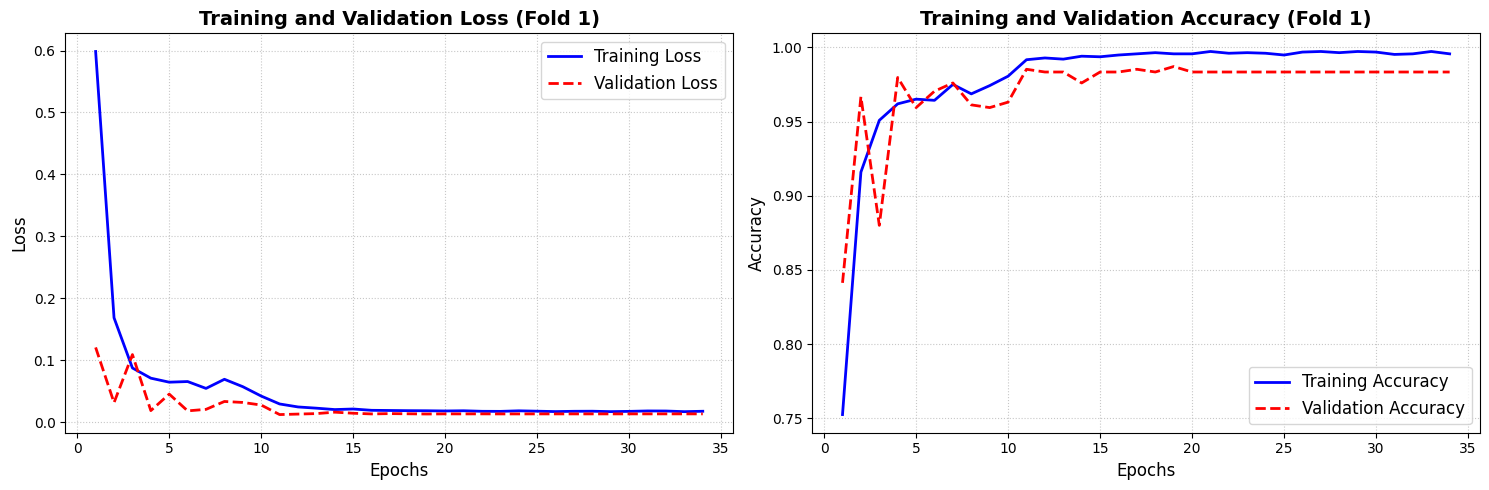

Initializing EdgeNeXt-XXS student model...
Total params: 1,158,723
Trainable params: 1,158,723


   Fold      Loss  Accuracy
0     1  0.013389  0.987085

Classification Report (Fold 1):
                  precision    recall  f1-score   support

    Glioma Tumor       0.99      0.99      0.99       245
Meningioma Tumor       0.96      0.98      0.97       112
 Pituitary Tumor       1.00      0.99      0.99       185

        accuracy                           0.99       542
       macro avg       0.98      0.99      0.98       542
    weighted avg       0.99      0.99      0.99       542



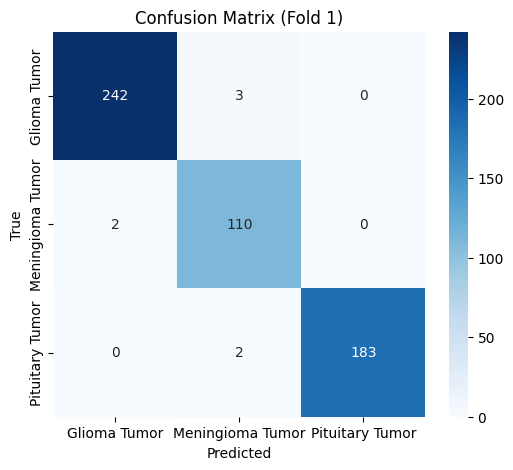

Generating extraction loader for Fold 2 (combining other 4 subsets)...
Dataset loaded for Fold 2. Total samples to extract: 2385
Extracting probabilities from Model 1 (DenseNet121)...


Extracting probabilities from Model 2 (MobileNet)...


Extracting probabilities from Model 3 (ResNet50)...


Extraction complete for Fold 2. Artifacts saved to: /kaggle/working/fold_2
Distillation DataLoader ready for Fold 2! Total samples: 2385, Total batches: 75
Initializing EdgeNeXt-XXS student model...


Epoch 1/100 | loss: 0.4298 - accuracy: 0.8080 | val_loss: 0.0761 - val_accuracy: 0.9131
val_accuracy improved from 0.0000 to 0.9131, saving weights to /kaggle/working/fold_2/student_distilled.pth


...

Epoch 30/100 | loss: 0.0127 - accuracy: 0.9983 | val_loss: 0.0462 - val_accuracy: 0.9470
val_accuracy did not improve from 0.9499


Epoch 31/100 | loss: 0.0123 - accuracy: 0.9996 | val_loss: 0.0465 - val_accuracy: 0.9470
val_accuracy did not improve from 0.9499


Epoch 32/100 | loss: 0.0122 - accuracy: 0.9996 | val_loss: 0.0465 - val_accuracy: 0.9470
val_accuracy did not improve from 0.9499


Epoch 33/100 | loss: 0.0129 - accuracy: 0.9992 | val_loss: 0.0465 - val_accuracy: 0.9470
val_accuracy did not improve from 0.9499


Epoch 34/100 | loss: 0.0130 - accuracy: 0.9987 | val_loss: 0.0465 - val_accuracy: 0.9470
val_accuracy did not improve from 0.9499
early stopping, restoring model weights from the end of the best epoch
Plot successfully saved to: /kaggle/working/fold_2/learning_curve_fold_2.png


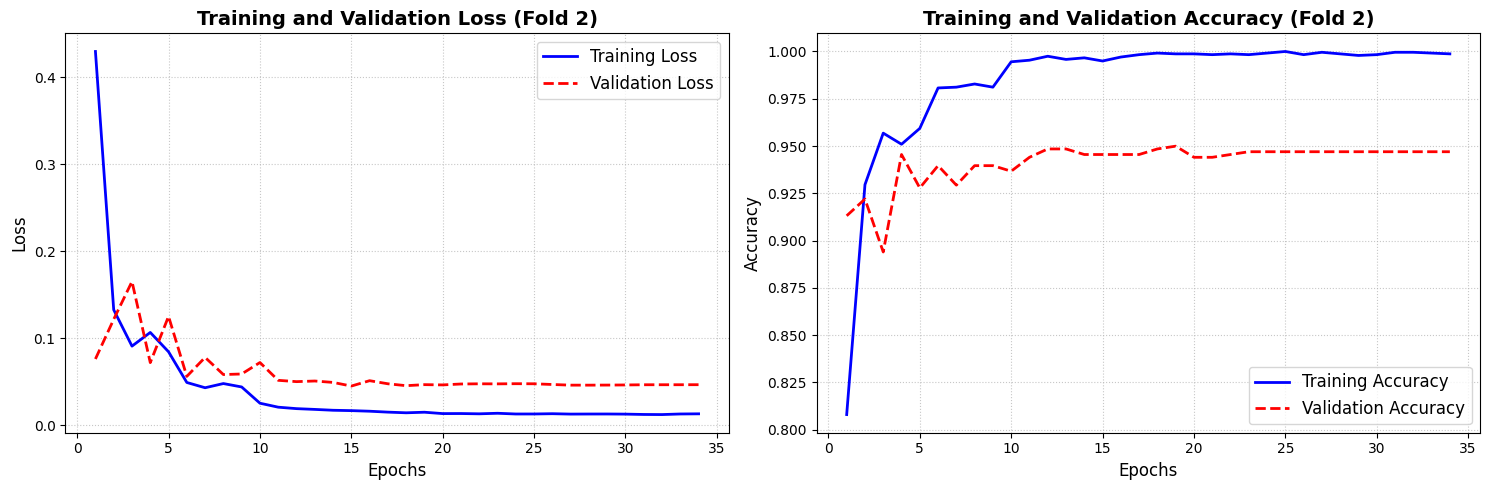

Initializing EdgeNeXt-XXS student model...
Total params: 1,158,723
Trainable params: 1,158,723


   Fold      Loss  Accuracy
0     2  0.046599  0.949926

Classification Report (Fold 2):
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.97      0.96       338
Meningioma Tumor       0.92      0.92      0.92       167
 Pituitary Tumor       0.98      0.95      0.96       174

        accuracy                           0.95       679
       macro avg       0.95      0.94      0.95       679
    weighted avg       0.95      0.95      0.95       679



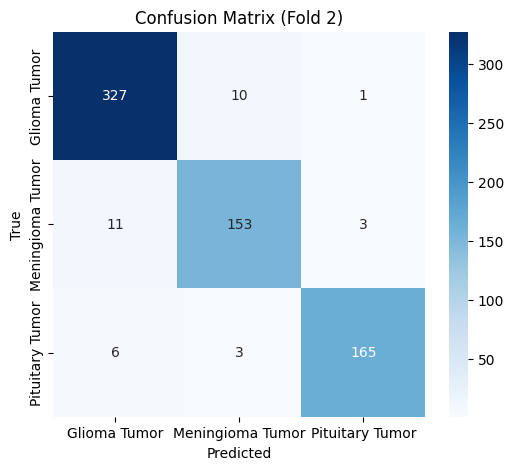

Generating extraction loader for Fold 3 (combining other 4 subsets)...
Dataset loaded for Fold 3. Total samples to extract: 2492
Extracting probabilities from Model 1 (DenseNet121)...


Extracting probabilities from Model 2 (MobileNet)...


Extracting probabilities from Model 3 (ResNet50)...


Extraction complete for Fold 3. Artifacts saved to: /kaggle/working/fold_3
Distillation DataLoader ready for Fold 3! Total samples: 2492, Total batches: 78
Initializing EdgeNeXt-XXS student model...


Epoch 1/100 | loss: 0.5291 - accuracy: 0.7364 | val_loss: 0.1189 - val_accuracy: 0.8829
val_accuracy improved from 0.0000 to 0.8829, saving weights to /kaggle/working/fold_3/student_distilled.pth


...

Epoch 19/100 | loss: 0.0127 - accuracy: 0.9988 | val_loss: 0.0371 - val_accuracy: 0.9580
val_accuracy did not improve from 0.9685


Epoch 20/100 | loss: 0.0124 - accuracy: 0.9992 | val_loss: 0.0370 - val_accuracy: 0.9563
val_accuracy did not improve from 0.9685


Epoch 21/100 | loss: 0.0124 - accuracy: 1.0000 | val_loss: 0.0371 - val_accuracy: 0.9563
val_accuracy did not improve from 0.9685


Epoch 22/100 | loss: 0.0126 - accuracy: 1.0000 | val_loss: 0.0366 - val_accuracy: 0.9563
val_accuracy did not improve from 0.9685


Epoch 23/100 | loss: 0.0120 - accuracy: 0.9988 | val_loss: 0.0369 - val_accuracy: 0.9563
val_accuracy did not improve from 0.9685
early stopping, restoring model weights from the end of the best epoch
Plot successfully saved to: /kaggle/working/fold_3/learning_curve_fold_3.png


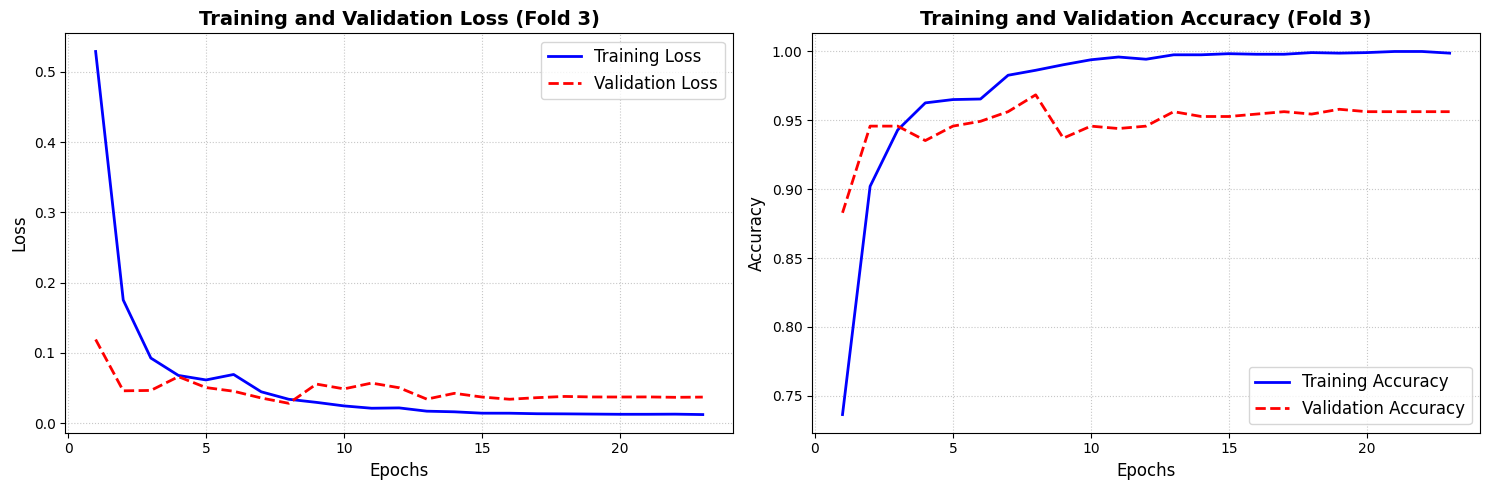

Initializing EdgeNeXt-XXS student model...
Total params: 1,158,723
Trainable params: 1,158,723


   Fold      Loss  Accuracy
0     3  0.028027  0.968531

Classification Report (Fold 3):
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.97      0.97       231
Meningioma Tumor       0.95      0.92      0.93       139
 Pituitary Tumor       0.98      1.00      0.99       202

        accuracy                           0.97       572
       macro avg       0.97      0.96      0.96       572
    weighted avg       0.97      0.97      0.97       572



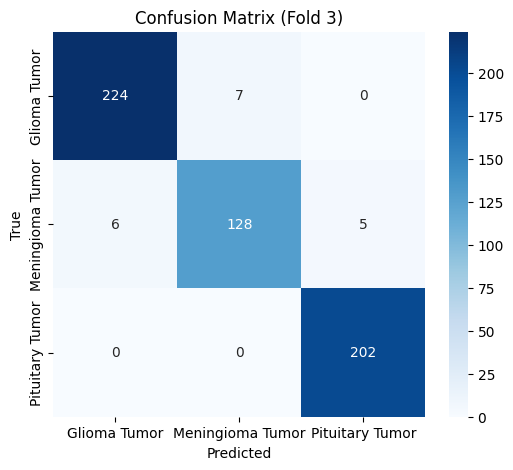

Generating extraction loader for Fold 4 (combining other 4 subsets)...
Dataset loaded for Fold 4. Total samples to extract: 2436
Extracting probabilities from Model 1 (DenseNet121)...


Extracting probabilities from Model 2 (MobileNet)...


Extracting probabilities from Model 3 (ResNet50)...


Extraction complete for Fold 4. Artifacts saved to: /kaggle/working/fold_4
Distillation DataLoader ready for Fold 4! Total samples: 2436, Total batches: 77
Initializing EdgeNeXt-XXS student model...


Epoch 1/100 | loss: 0.6259 - accuracy: 0.7508 | val_loss: 0.2684 - val_accuracy: 0.8248
val_accuracy improved from 0.0000 to 0.8248, saving weights to /kaggle/working/fold_4/student_distilled.pth


...

Epoch 25/100 | loss: 0.0168 - accuracy: 0.9971 | val_loss: 0.0308 - val_accuracy: 0.9793
val_accuracy did not improve from 0.9841


Epoch 26/100 | loss: 0.0162 - accuracy: 0.9992 | val_loss: 0.0309 - val_accuracy: 0.9777
val_accuracy did not improve from 0.9841


Epoch 27/100 | loss: 0.0163 - accuracy: 0.9988 | val_loss: 0.0308 - val_accuracy: 0.9793
val_accuracy did not improve from 0.9841


Epoch 28/100 | loss: 0.0162 - accuracy: 0.9992 | val_loss: 0.0307 - val_accuracy: 0.9793
val_accuracy did not improve from 0.9841


Epoch 29/100 | loss: 0.0160 - accuracy: 0.9988 | val_loss: 0.0308 - val_accuracy: 0.9793
val_accuracy did not improve from 0.9841
early stopping, restoring model weights from the end of the best epoch
Plot successfully saved to: /kaggle/working/fold_4/learning_curve_fold_4.png


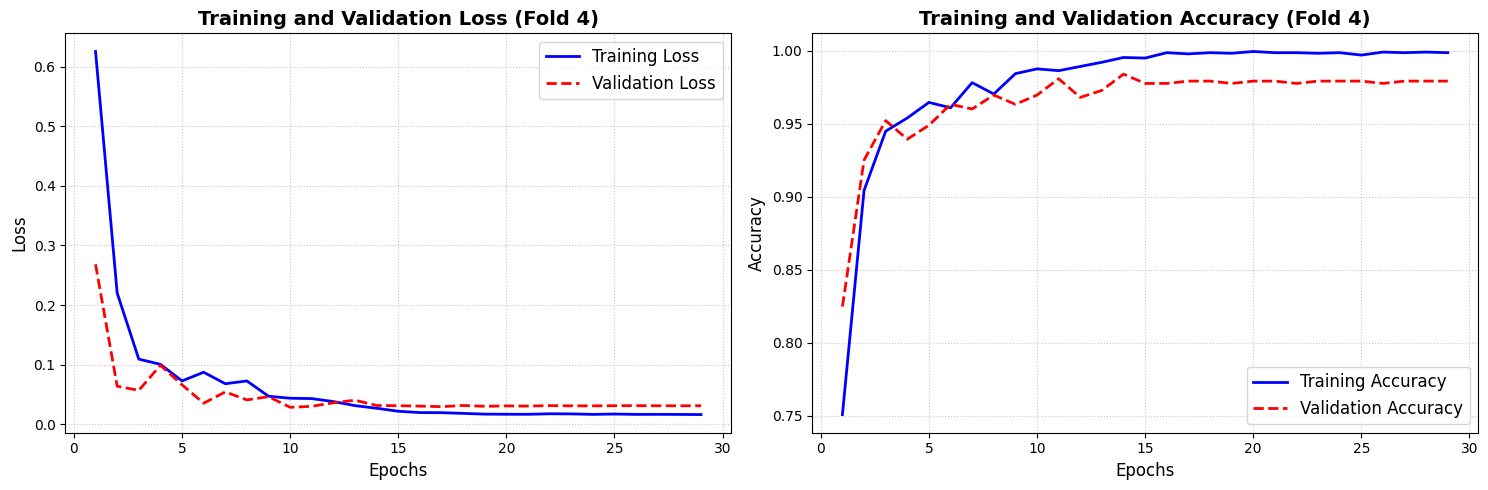

Initializing EdgeNeXt-XXS student model...
Total params: 1,158,723
Trainable params: 1,158,723


   Fold      Loss  Accuracy
0     4  0.031249  0.984076

Classification Report (Fold 4):
                  precision    recall  f1-score   support

    Glioma Tumor       0.99      1.00      0.99       325
Meningioma Tumor       0.97      0.96      0.96       124
 Pituitary Tumor       0.99      0.98      0.98       179

        accuracy                           0.98       628
       macro avg       0.98      0.98      0.98       628
    weighted avg       0.98      0.98      0.98       628



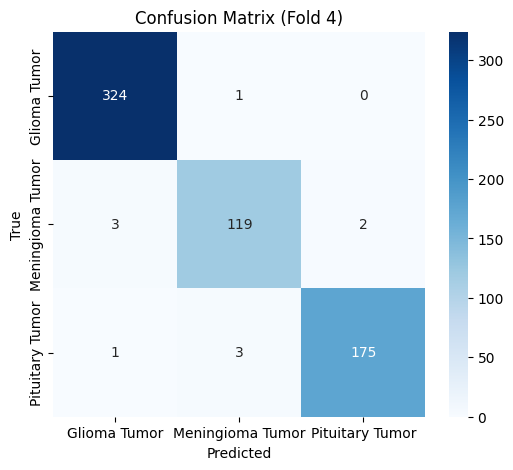

Generating extraction loader for Fold 5 (combining other 4 subsets)...
Dataset loaded for Fold 5. Total samples to extract: 2421
Extracting probabilities from Model 1 (DenseNet121)...


Extracting probabilities from Model 2 (MobileNet)...


Extracting probabilities from Model 3 (ResNet50)...


Extraction complete for Fold 5. Artifacts saved to: /kaggle/working/fold_5
Distillation DataLoader ready for Fold 5! Total samples: 2421, Total batches: 76
Initializing EdgeNeXt-XXS student model...


Epoch 1/100 | loss: 0.5234 - accuracy: 0.8232 | val_loss: 0.1448 - val_accuracy: 0.8927
val_accuracy improved from 0.0000 to 0.8927, saving weights to /kaggle/working/fold_5/student_distilled.pth


...

Epoch 25/100 | loss: 0.0170 - accuracy: 0.9967 | val_loss: 0.1250 - val_accuracy: 0.9456
val_accuracy did not improve from 0.9487


Epoch 26/100 | loss: 0.0172 - accuracy: 0.9959 | val_loss: 0.1247 - val_accuracy: 0.9456
val_accuracy did not improve from 0.9487


Epoch 27/100 | loss: 0.0160 - accuracy: 0.9979 | val_loss: 0.1248 - val_accuracy: 0.9456
val_accuracy did not improve from 0.9487


Epoch 28/100 | loss: 0.0172 - accuracy: 0.9975 | val_loss: 0.1248 - val_accuracy: 0.9456
val_accuracy did not improve from 0.9487


Epoch 29/100 | loss: 0.0169 - accuracy: 0.9975 | val_loss: 0.1248 - val_accuracy: 0.9456
val_accuracy did not improve from 0.9487
early stopping, restoring model weights from the end of the best epoch
Plot successfully saved to: /kaggle/working/fold_5/learning_curve_fold_5.png


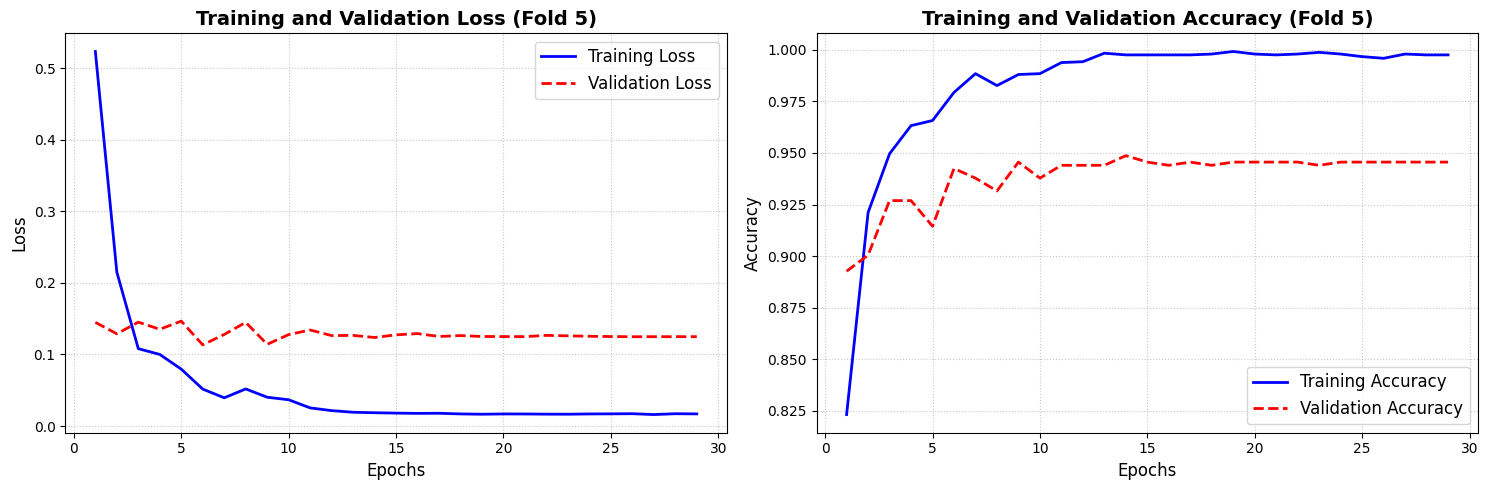

Initializing EdgeNeXt-XXS student model...
Total params: 1,158,723
Trainable params: 1,158,723


   Fold      Loss  Accuracy
0     5  0.123682  0.948678

Classification Report (Fold 5):
                  precision    recall  f1-score   support

    Glioma Tumor       1.00      0.97      0.98       287
Meningioma Tumor       0.94      0.87      0.90       166
 Pituitary Tumor       0.90      0.99      0.94       190

        accuracy                           0.95       643
       macro avg       0.94      0.94      0.94       643
    weighted avg       0.95      0.95      0.95       643



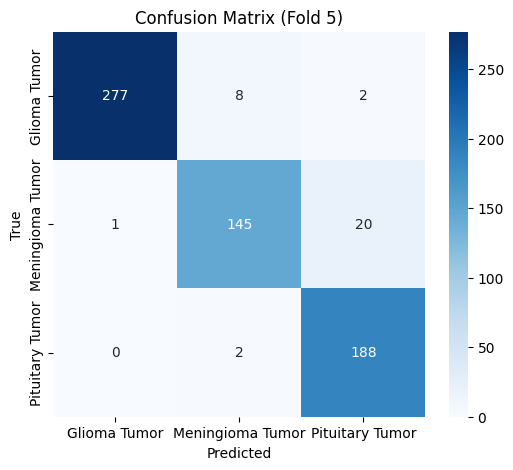


Final accuracy: 96.77%


In [34]:
fold_accuracies = []

for k in range(1, 6):
    current_model1_path = os.path.join(MODEL1_DIR, f'{MODEL1_NAME}_block_2_fold_{k}.pth')
    current_model2_path = os.path.join(MODEL2_DIR, f'{MODEL2_NAME}_block_1_fold_{k}.pth')
    current_model3_path = os.path.join(MODEL3_DIR, f'{MODEL3_NAME}_block_1_fold_{k}.pth')

    # 1. Initialize soft labels
    generate_ensemble_soft_labels(
        k=k, 
        model1_path=current_model1_path,
        model2_path=current_model2_path,
        model3_path=current_model3_path
    )

    # 2. Initialize DataLoaders for fold k
    train_distill_loader = get_distillation_loader(k=k)
    val_loader = get_valid_data_for_fold(k=k)

    fold_acc = test_student_distillation(
        k=k,
        train_loader=train_distill_loader,
        val_loader=val_loader
    )
    fold_accuracies.append(fold_acc)

# 3. 5 folds avg
avg_acc = sum(fold_accuracies) / len(fold_accuracies)
print(f"\nFinal accuracy: {avg_acc*100:.2f}%")